In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('inference/methods/scores.csv', index_col=0)

In [3]:
df.columns

Index(['tripod_mobivital_post_invert.txt',
       'tripod_mobivital_post_invert.txt_no_inv',
       'tripod_mobivital_pre_invert_0.9.txt', 'tripod_cfar_abs.txt_no_inv',
       'tripod_cfar_abs.txt', 'tripod_std_abs.txt_no_inv',
       'tripod_std_abs.txt', 'tripod_fft_noinv.txt', 'tripod_fft_preinv.txt',
       'tripod_oracle.txt'],
      dtype='object')

In [4]:
data = df.to_dict(orient='list')

In [5]:
file_to_name = {
    'tripod_mobivital_pre_invert_0.9.txt': 'Mobivital(proposed)',
    'tripod_cfar_abs.txt': 'CFAR',
    'tripod_std_abs.txt': 'Variance',
    'tripod_fft_preinv.txt': 'SNR',
    'tripod_oracle.txt': 'Oracle'
}

CDF of Various Methods


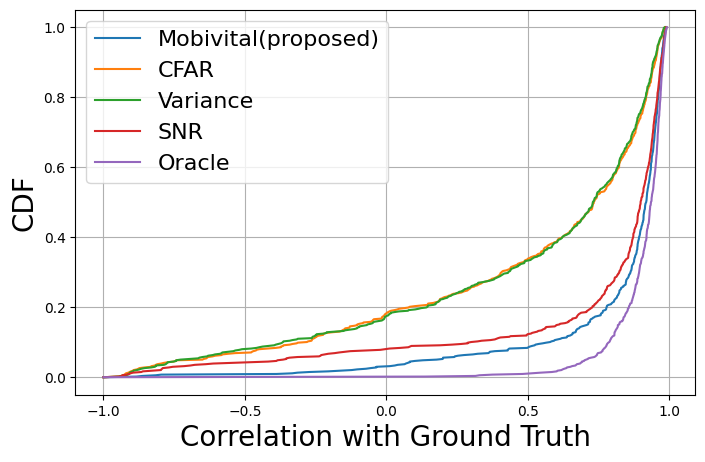

In [ ]:
plt.figure(figsize=(8, 5))

for key in file_to_name.keys():
    val = data[key]
    # remove nans
    val = [x for x in val if not np.isnan(x)]
    avg_val = np.mean(val)
    print(file_to_name[key], avg_val)
    val = sorted(val)
    cdf = np.arange(1, len(val) + 1) / len(val)
    
    val = [-1] + val
    cdf = [0] + list(cdf)
    plt.plot(val, cdf, label=file_to_name[key])

plt.xlabel('Correlation with Ground Truth', fontsize=20)
plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.ylabel('CDF', fontsize=20)
plt.legend(fontsize=16)
plt.grid()
#plt.title('CDF of Various Methods', fontsize=20)
print('CDF of Various Methods')


In [36]:
file_to_name = {
    'tripod_mobivital_post_invert.txt_no_inv': 'Mobivital(proposed)',
    'tripod_cfar_abs.txt_no_inv': 'CFAR',
    'tripod_std_abs.txt_no_inv': 'Variance',
    'tripod_fft_noinv.txt': 'SNR',
    'tripod_oracle.txt': 'Oracle'
}

Mobivital(proposed) 0.8157974565287449
CFAR 0.21781578284021472
Variance 0.22492772410196
SNR 0.4745177567044279
Oracle 0.9028739325307212
CDF of Various Methods


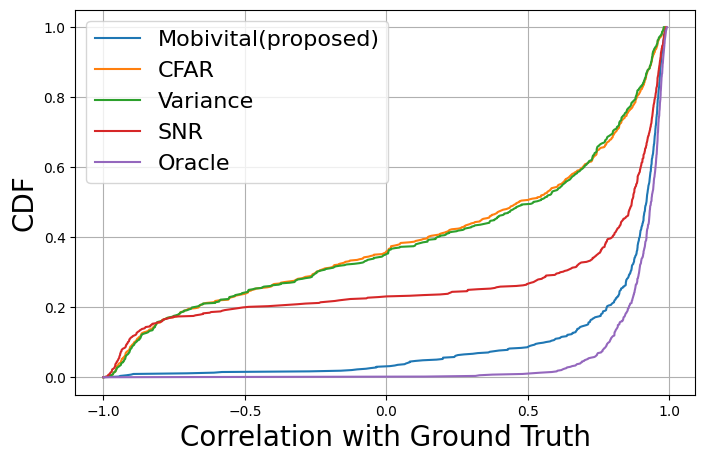

In [37]:
plt.figure(figsize=(8, 5))

for key in file_to_name.keys():
    val = data[key]
    # remove nans
    val = [x for x in val if not np.isnan(x)]
    avg_val = np.mean(val)
    print(file_to_name[key], avg_val)
    val = sorted(val)
    cdf = np.arange(1, len(val) + 1) / len(val)
    
    val = [-1] + val
    cdf = [0] + list(cdf)
    plt.plot(val, cdf, label=file_to_name[key])

plt.xlabel('Correlation with Ground Truth', fontsize=20)
plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.ylabel('CDF', fontsize=20)
plt.legend(fontsize=16)
plt.grid()
#plt.title('CDF of Various Methods', fontsize=20)
print('CDF of Various Methods')


In [48]:
import torch
import json
import os

from einops import rearrange
from tqdm.notebook import tqdm, trange
from training.utils.models import *
from peak_width_inverter import invert_detector
from training.utils.model_utils import self_normalize, sequence_transforms, softmax
device = 'cuda:3'

In [49]:
from bunch import Bunch
args = Bunch()
with open('optimal_params.json', 'r') as f:
    params = json.load(f)
    for key, value in params.items():
        args[key] = value

args.model_folder = './models'
args.model_name = 'lstm_pred_tripod_0.9.pth'
args.mode = 'tripod'
args.bar=0.8
args.data_folder = './data_final'

In [50]:
def get_best_sequence(original_sequence, model, history_len=args.history_length, future_len=args.future_length):
    
    original_sequence = rearrange(original_sequence, "t c -> c t")

    sequences = []
    for s in original_sequence:
        sequences += sequence_transforms(s)

    filtered_sequences = []
    index_map = {}
    counter = 0
    for i, seq in enumerate(sequences):
        if invert_detector(seq) < args.bar:
            index_map[counter] = i
            counter += 1
            filtered_sequences.append(seq)

    sequences = np.array(filtered_sequences)
    # (36, 1500)
    steps_forward = future_len
    
    X = []
    y = []
    for i in range(len(sequences)):
        if sequences[i] is None:
            continue
        seq = sequences[i,...]
        start_idx = 0
        end_idx = start_idx + history_len + future_len
        while end_idx <= len(seq):
            X.append(seq[start_idx:start_idx+history_len])
            y.append(seq[start_idx+history_len:end_idx])
            start_idx += steps_forward
            end_idx = start_idx + history_len + future_len
    X = np.array(X)
    y = np.array(y)
    with torch.no_grad():
        inputs = torch.from_numpy(X).to(device)
        labels = torch.from_numpy(y).to(device)
        outputs = model(inputs)
    losses = []
    for sample in range(len(labels)):
        losses.append(np.corrcoef(outputs[sample].cpu().numpy(), labels[sample].cpu().numpy())[0,1])
    losses = np.array(losses)
    l = (1500 - history_len) // future_len
    losses = rearrange(losses, "(c l) -> c l", l=l)
    min_loss_idx = np.argmax(np.sum(losses, axis=1))
    self_corr = np.average(losses[min_loss_idx])
    return sequences[min_loss_idx], index_map[min_loss_idx], self_corr

In [51]:
def inference(autoreg_model, X_uwb, y_breath):
    self_corr_list = []
    gt_corr_list = []
    print(X_uwb.shape)

    for i in trange(len(y_breath)):
        best_sequence, best_idx, self_corr = get_best_sequence(X_uwb[i], autoreg_model)
        # convert the best sequence to features for invert model     
        gt_corr = np.corrcoef(self_normalize(y_breath[i]), best_sequence)[0][1]           
        
        self_corr_list.append(self_corr)
        gt_corr_list.append(gt_corr)
        
    return self_corr_list, gt_corr_list

In [52]:
X_uwb = np.array([])
y_breath = np.array([])
with open(f'{args.data_folder}/training_breath_{args.mode}_data.npy', 'rb') as f:
    X_uwb = np.load(f)
    y_breath = np.load(f)

model = LSTMMultiStep(args.hidden_size, args.num_layers, args.future_length)
model.load_state_dict(torch.load(os.path.join(args.model_folder, args.model_name)))
model.to(device)

self_corr_list, gt_corr_list = inference(model, X_uwb, y_breath)

(1297, 1500, 120)


  0%|          | 0/1297 [00:00<?, ?it/s]

MobiVital Selected Sequences r: 0.50


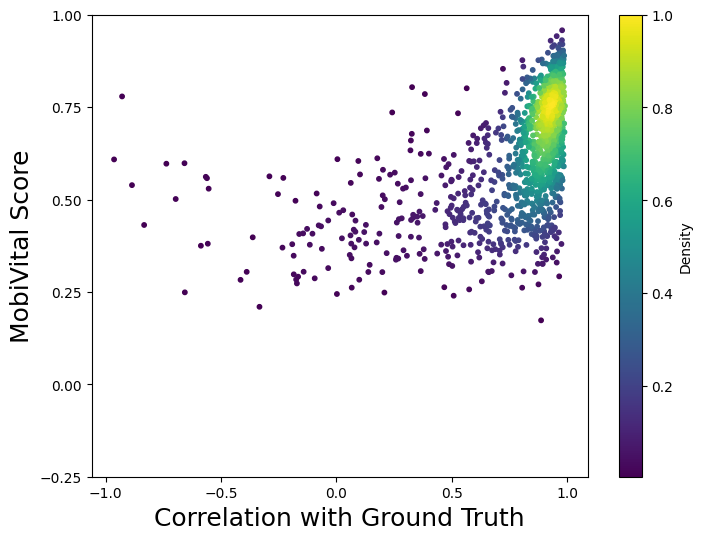

In [69]:
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.figure(figsize=(8, 6))

x = gt_corr_list
y = self_corr_list
# Calculate point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
z = z / z.max()

points = plt.scatter(x, y, c=z, s=10, cmap='viridis')
plt.colorbar(points, label='Density')

plt.xlabel('Correlation with Ground Truth', fontsize=18)
plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.ylabel('MobiVital Score', fontsize=18)
plt.yticks([-0.25, 0, 0.25, 0.5, 0.75, 1])
#plt.grid()
#plt.title('\nAutoregressive Correlation vs Ground Truth Correlation', fontsize=12)
#plt.suptitle('MobiVital Selected Sequences', fontsize=24)
print('MobiVital Selected Sequences', f"r: {np.corrcoef(x, y)[0,1]:.2f}")


In [90]:
from CalcSNR import calc_snr

def get_best_sequence(original_sequence):
    
    original_sequence = rearrange(original_sequence, "t c -> c t")

    sequences = []
    for s in original_sequence:
        sequences += sequence_transforms(s)

    filtered_sequences = []
    index_map = {}
    counter = 0
    for i, seq in enumerate(sequences):
        if invert_detector(seq) < args.bar:
            index_map[counter] = i
            counter += 1
            filtered_sequences.append(seq)

    sequences = np.array(filtered_sequences)
    # (36, 1500)
    best_score = float('-inf')
    best_sequence = None
    for sequence in sequences:
        seq_score = calc_snr(sequence)    
        if seq_score > best_score:
            best_score = seq_score
            best_sequence = sequence
    
    return best_sequence, best_score

In [91]:
def inference(X_uwb, y_breath):
    self_corr_list = []
    gt_corr_list = []
    print(X_uwb.shape)

    for i in trange(len(y_breath)):
        best_sequence, self_corr = get_best_sequence(X_uwb[i])
        # convert the best sequence to features for invert model     
        gt_corr = np.corrcoef(self_normalize(y_breath[i]), best_sequence)[0][1]           
        
        self_corr_list.append(self_corr)
        gt_corr_list.append(gt_corr)
        
    return self_corr_list, gt_corr_list

In [92]:
X_uwb = np.array([])
y_breath = np.array([])
with open(f'{args.data_folder}/training_breath_{args.mode}_data.npy', 'rb') as f:
    X_uwb = np.load(f)
    y_breath = np.load(f)

self_corr_list, gt_corr_list = inference( X_uwb, y_breath)

(1297, 1500, 120)


  0%|          | 0/1297 [00:00<?, ?it/s]

R^2 value: 0.35
SNR Selected Sequences r: 0.59


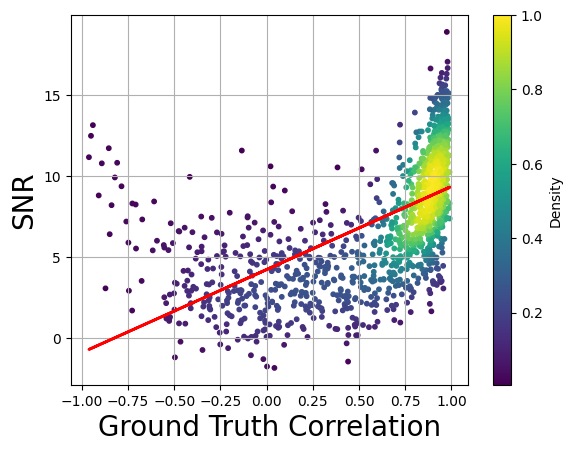

In [94]:
plt.figure(figsize=(8, 6))

from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Reshape the data
x = np.array(x).reshape(-1, 1)
y = np.array(y)

# Fit the model
model = LinearRegression()
model.fit(x, y)

# Predict
y_pred = model.predict(x)

# Calculate R^2 value
r2 = r2_score(y, y_pred)
print(f"R^2 value: {r2:.2f}")

# Plot the line of best fit
plt.plot(x, y_pred, color='red', linewidth=2)
x = gt_corr_list
y = self_corr_list
# Calculate point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
z = z / z.max()

points = plt.scatter(x, y, c=z, s=10, cmap='viridis')
plt.colorbar(points, label='Density')

plt.xlabel('Ground Truth Correlation', fontsize=20)
#plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.ylabel('SNR', fontsize=20)
#plt.yticks([-1, -0.5, 0, 0.5, 1])
plt.grid()
print('SNR Selected Sequences', f"r: {np.corrcoef(x, y)[0,1]:.2f}")


In [31]:
df = pd.read_csv('inference/methods/mobivital.csv', index_col=0)

In [32]:
data = df.to_dict(orient='list')

Text(0.5, 1.0, 'Correlation Coefficient Comparison')

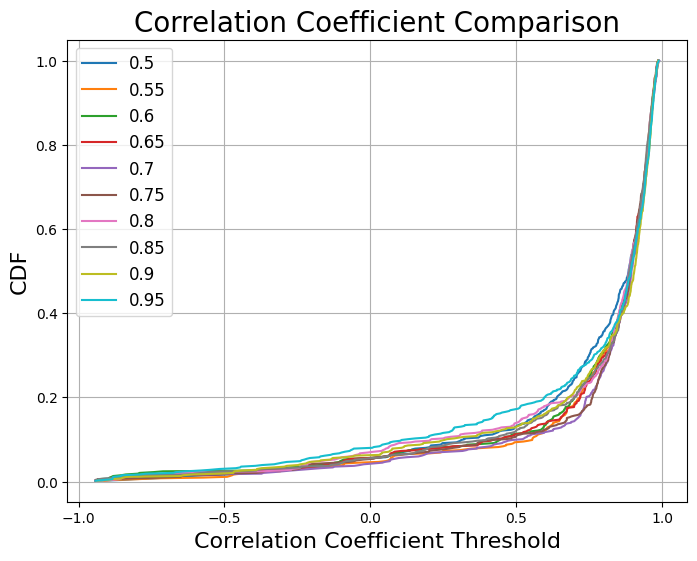

In [33]:
plt.figure(figsize=(8, 6))

for key in data.keys():
    val = data[key]
    val = np.array(val)

    val = sorted(val)
    cdf = np.arange(1, len(val) + 1) / len(val)
    threshold = float(key.split('_')[-1][:-4])

    plt.plot(val, cdf, label=threshold)

plt.xlabel('Correlation Coefficient Threshold', fontsize=16)
plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.ylabel('CDF', fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.title('Correlation Coefficient Comparison', fontsize=20)

MobiVital Score vs Correlation Threshold


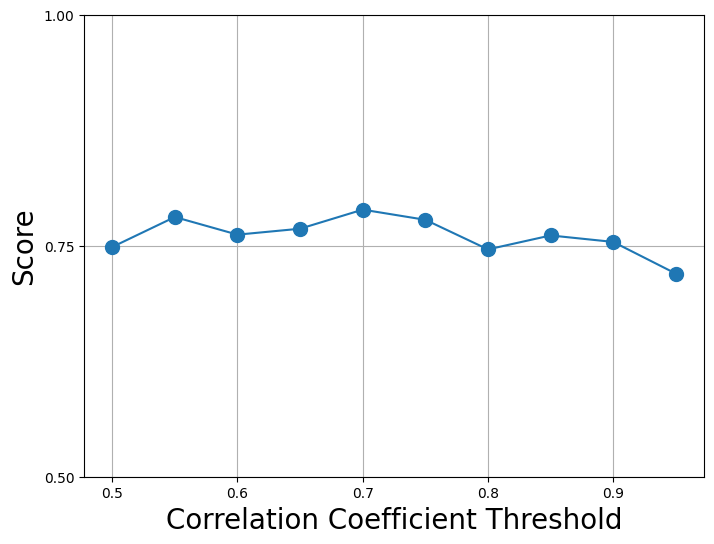

In [35]:
plt.figure(figsize=(8, 6))

thresholds = []
scores = []

for key in data.keys():
    val = data[key]
    score = np.average(np.array(val))
    if score == None:
        print(key)
    threshold = float(key.split('_')[-1][:-4])
    thresholds.append(threshold)
    scores.append(score)
plt.plot(thresholds, scores, linestyle='-', marker='o', markersize=10)

plt.xlabel('Correlation Coefficient Threshold', fontsize=20)
plt.ylabel('Score', fontsize=20)
plt.yticks([0.5, 0.75, 1])
plt.grid()
print('MobiVital Score vs Correlation Threshold')
#plt.title('Correlation Coefficient Comparison', fontsize=20)

In [47]:
df = pd.read_csv('inference/methods/inversion.csv', index_col=0)

In [48]:
data = df.to_dict(orient='list')

In [49]:
df.columns

Index(['tripod_mobivital_post_invert.txt',
       'tripod_mobivital_post_invert.txt_no_inv',
       'tripod_mobivital_pre_invert_0.9.txt', 'tripod_cfar_abs.txt_no_inv',
       'tripod_cfar_abs.txt', 'tripod_std_abs.txt_no_inv',
       'tripod_std_abs.txt', 'tripod_oracle.txt', 'tripod_fft_preinv.txt',
       'tripod_fft_noinv.txt'],
      dtype='object')

In [50]:
file_to_name = {
    'tripod_mobivital_pre_invert_0.9.txt': 'Mobivital\nPre Inv',
    'tripod_mobivital_post_invert.txt_no_inv': 'Mobivital\nNo Inv',

    'tripod_fft_preinv.txt': 'FFT\nPre Inv',
    'tripod_fft_noinv.txt': 'FFT\nNo Inv',

    'tripod_cfar_abs.txt': 'CFAR\nPost Inv',
    'tripod_cfar_abs.txt_no_inv': 'CFAR\nNo Inv',

    'tripod_std_abs.txt': 'STD\nPost Inv',
    'tripod_std_abs.txt_no_inv': 'STD\nNo Inv',
    'tripod_oracle.txt': 'Oracle',
}

In [51]:
for idx, (key, name) in enumerate(file_to_name.items()):
    val = data[key]
    score = np.average(np.array(val))
    print(name.replace('\n', ' '), score)

Mobivital Pre Inv 0.8017991318018194
Mobivital No Inv 0.7794344726868152
FFT Pre Inv 0.7450875248503954
FFT No Inv 0.4745177567044279
CFAR Post Inv 0.5156065698552794
CFAR No Inv 0.21781578284021472
STD Post Inv 0.5135709190397771
STD No Inv 0.22492772410196
Oracle 0.9426654043982957


In [38]:
file_to_name = {
    'tripod_mobivital_pre_invert_0.9.txt': 'Mobivital\nPre Inv',
    'tripod_mobivital_post_invert.txt_no_inv': 'Mobivital\nNo Inv',

    'tripod_fft_preinv.txt': 'FFT\nPre Inv',
    'tripod_fft_noinv.txt': 'FFT\nNo Inv',

    'tripod_cfar_abs.txt': 'CFAR\nPost Inv',
    'tripod_cfar_abs.txt_no_inv': 'CFAR\nNo Inv',

    'tripod_std_abs.txt': 'STD\nPost Inv',
    'tripod_std_abs.txt_no_inv': 'STD\nNo Inv',
}

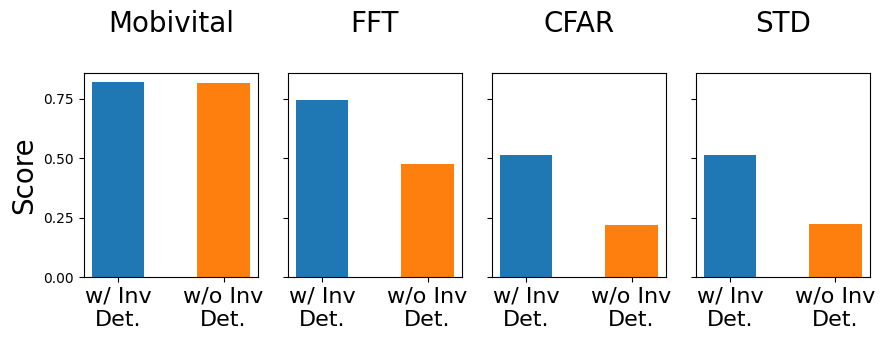

In [72]:
scores = []
fig, axes = plt.subplots(1, len(file_to_name) // 2, figsize=(9, 3.5), sharey=True)

for idx, (key, name) in enumerate(file_to_name.items()):
    val = data[key]
    score = np.average(np.array(val))
    scores.append(score)
    ax = axes[idx // 2]
    if idx == 0:
        ax.set_ylabel('Score', fontsize=20)
        ax.set_yticks([0, 0.25, 0.5, 0.75])
        #ax.set_ylim(0, 0.75)
        
    if idx % 2 == 0:
        ax.bar('Invert', score, 0.5)

    else:
        ax.bar('No Invert', score, 0.5)
        ax.set_xticks([0, 1])  # Set the ticks first
        ax.set_xticklabels(['w/ Inv\nDet.', 'w/o Inv\nDet.'], fontsize=16)

    ax.set_title(name[:-6], fontsize=20)

#for ax in axes:
#    ax.grid(axis='y')
#fig.suptitle('Inversion Comparison', fontsize=24)
fig.tight_layout()

In [6]:
#'User G (134)'
#'User H (138)'
#'User I (145)'
#'User J (120)'

'''
user G
score 0.922588815190433
mobivital score 0.7715770652357357
oracle score 0.9523299639335003
'''

'''
User H
score 0.6907441539365466
mobivital score 0.5079833555157242
oracle score 0.9108305819982333
'''

'''
User I
score 0.7657985167879565
mobivital score 0.5944052140098857
oracle score 0.9444253216972399
'''

'''
User J
score 0.9172580808410576
mobivital score 0.7115034806074727
oracle score 0.9663567919411632
'''

test_user_scores = {
    'Subject G': 0.922588815190433,
    'Subject H': 0.6907441539365466,
    'Subject I': 0.7657985167879565,
    'Subject J': 0.9172580808410576
}

test_user_mobivital_scores = {
    'Subject G': 0.7715770652357357,
    'Subject H': 0.5079833555157242,
    'Subject I': 0.5944052140098857,
    'Subject J': 0.7115034806074727
}

test_user_oracle_scores = {
    'Subject G': 0.9523299639335003,
    'Subject H': 0.9108305819982333,
    'Subject I': 0.9444253216972399,
    'Subject J': 0.9663567919411632
}

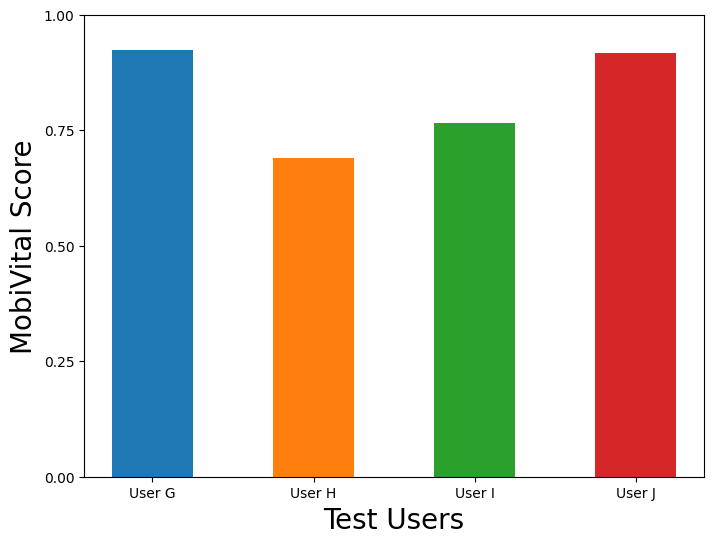

In [61]:
plt.figure(figsize=(8, 6))

for idx, (key, val) in enumerate(test_user_scores.items()):
    plt.bar(key, val, width=0.5)

plt.xlabel('Test Users', fontsize=20)
plt.ylabel('MobiVital Score', fontsize=20)
plt.yticks([0, 0.25, 0.50, 0.75, 1])
#plt.title('Test User Scores', fontsize=20)
plt.show()

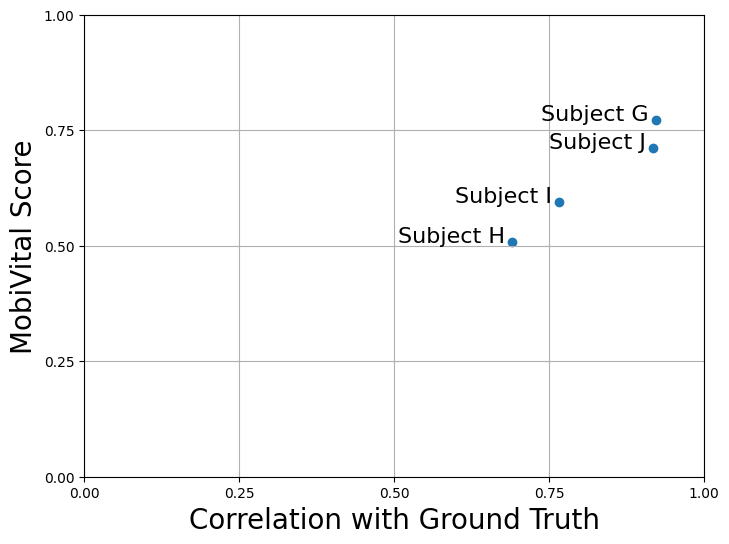

In [7]:
plt.figure(figsize=(8, 6))

# Extract the test user names and their corresponding scores
test_user_names = list(test_user_scores.keys())
test_user_values = list(test_user_scores.values())
mobivital_values = [test_user_mobivital_scores[user] for user in test_user_names]

# Plot the scores
plt.scatter(test_user_values, mobivital_values)#, color='blue', s=100)

# Add labels to the points
for i, user in enumerate(test_user_names):
    plt.text(test_user_values[i], mobivital_values[i], user+' ', fontsize=16, ha='right')

plt.xlabel('Correlation with Ground Truth', fontsize=20)
plt.ylabel('MobiVital Score', fontsize=20)
#plt.title('MobiVital Scores vs Test User Scores', fontsize=20)
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid(True)
plt.show()